# Self-Correcting Agentic Retrieval Loops

**Build an agent that adapts its retrieval strategy to the question.**

Most retrieval agents follow the same pipeline for every query. That wastes compute on easy questions, under-serves difficult ones, and often forces guesses when the evidence is insufficient.

In this lab you build a **self-correcting retrieval loop**. The agent retrieves once, evaluates the quality of the evidence using inexpensive signals, and only invokes more costly retrieval steps when needed.

The implementation uses Qdrant, FastEmbed, and an LLM, all built inline from those primitives - so you can lift any cell straight into your own code.

Roadmap:

- **CP1:** name the concepts and run the baseline retrieval.
- **CP2:** connect those concepts to metrics, signals, thresholds, and the signal gate.
- **CP3:** wire ColBERT, decompose, answer generation, and STOP into one loop.
- **Wrap:** read the held-out scorecard and adapt the method to your own corpus.

## Setup

This imports the external tools, loads the question set, connects to Qdrant, and warms the query
embedding models. On the workshop VM everything is already installed and indexed. When this cell
prints `Ready`, continue.

In [ ]:
import sys
import os
import json
import re
import string
import statistics
from pathlib import Path
from dataclasses import dataclass

from dotenv import load_dotenv
import pandas as pd
import numpy as np
import litellm
from qdrant_client import QdrantClient, models
from fastembed import TextEmbedding, SparseTextEmbedding, LateInteractionTextEmbedding
from sklearn.metrics import roc_auc_score
from IPython.display import display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))    # makes labkit (rendering) importable; the agent code lives in this notebook
load_dotenv(REPO / ".env")
os.environ.setdefault("LITELLM_LOG", "ERROR")
pd.set_option("display.precision", 3)

from labkit import (load_artifact, frontier_table, show_hits, show_run,
                    plot_signal_separation, plot_gate)

# --- inline constants (the collection schema, model ids, retrieval + answer sizes) ---
COLLECTION = "musique"
COLBERT_COLLECTION = "musique_colbert"             # dense + colbert multivector (Tier 2 showcase)
DENSE_MODEL = "BAAI/bge-base-en-v1.5"              # 768-d dense, cosine
MINICOIL_MODEL = "Qdrant/minicoil-v1"             # word-sense-aware sparse (the hybrid baseline's sparse)
COLBERT_MODEL = "answerdotai/answerai-colbert-small-v1"
DENSE_VEC, MINICOIL_VEC, COLBERT_VEC = "dense", "minicoil", "colbert"
RETRIEVE_N = 50          # per-retriever prefetch depth before fusion
TOP_K = 10               # signal / pool window
ANSWER_K = 3             # focused passages the LLM reads to answer
AGENT_MODEL = "anthropic/claude-sonnet-4-6"        # decompose + answer
FAST_MODEL = "anthropic/claude-haiku-4-5"          # the fast sufficiency autorater (STOP)

client = QdrantClient(url=os.environ.get("QDRANT_URL", "http://localhost:6333"), timeout=120)

# The query-side embedders. The corpus is already indexed in Qdrant; only these query models load here.
dense_model = TextEmbedding(DENSE_MODEL)
minicoil_model = SparseTextEmbedding(MINICOIL_MODEL)
colbert_model = LateInteractionTextEmbedding(COLBERT_MODEL)
for warm in (dense_model, minicoil_model):
    next(iter(warm.query_embed("warm up")))
next(iter(colbert_model.query_embed("warm up")))

# The question set (mixed workload), loaded straight from the dataset file.
by_id = {q["id"]: q for q in (json.loads(line) for line in (REPO / "data/questions_mixed.jsonl").open())}

main_count = client.count(COLLECTION, exact=True).count
assert main_count > 0, "collection empty - run scripts/setup_collections.py"
colbert_count = (client.count(COLBERT_COLLECTION, exact=True).count
                 if client.collection_exists(COLBERT_COLLECTION) else "absent")
api_keys_loaded = bool(os.environ.get("ANTHROPIC_API_KEY"))

print(f"Qdrant '{COLLECTION}': {main_count} points  |  '{COLBERT_COLLECTION}': {colbert_count} points")
print(f"dense ({DENSE_MODEL}) + sparse (minicoil), fused with RRF")
print(f"loaded {len(by_id)} questions; embedding models warm; answer context = top-{ANSWER_K}")
print(f"API key loaded: {api_keys_loaded}")
print("\nReady" if main_count and api_keys_loaded else "\nNOT ready")

## The LLM call

The agent uses an LLM for three tasks: generating decomposition queries, producing the final answer, and deciding when enough evidence has been collected. All three are routed through a single helper configured for deterministic output `temperature=0` with automatic retries for transient API failures.

In [ ]:
def ask_llm(system, user, max_tokens=256, model=AGENT_MODEL, temperature=0.0):
    # one deterministic LLM turn via LiteLLM; num_retries rides out transient API blips.
    litellm.suppress_debug_info = True
    resp = litellm.completion(
        model=model,
        messages=[{"role": "system", "content": system},
                  {"role": "user", "content": user}],
        max_tokens=max_tokens, temperature=temperature, timeout=45, num_retries=3,
    )
    return (resp.choices[0].message.content or "").strip()

## CP1: concepts, baseline, and failure modes

The workload has three kinds of questions:

| kind | what has to happen |
|---|---|
| single-hop | one retrieved passage contains the answer |
| multi-hop | the first passage reveals another thing to look up |
| unanswerable | the corpus does not contain enough evidence, so the agent should abstain |

The baseline is one **hybrid** retrieval, then answer. Hybrid means Qdrant gets candidates two ways:
dense vectors find semantic matches, sparse miniCOIL finds lexical matches, and RRF fuses the ranks.
This cell defines that baseline retrieval and the lightweight `Passage` object reused later.

In [ ]:
def embed(text):
    # the two query-side embeddings used everywhere: dense (bge) + miniCOIL sparse.
    dense = next(iter(dense_model.query_embed(text))).tolist()
    minicoil = next(iter(minicoil_model.query_embed(text)))
    return dense, minicoil

def hybrid_search(question, limit=TOP_K, enc=None):
    # Qdrant hybrid retrieval: dense + miniCOIL prefetched (top-50 each), fused server-side with RRF.
    dense, minicoil = enc or embed(question)
    return client.query_points(
        COLLECTION,
        prefetch=[
            models.Prefetch(query=dense, using=DENSE_VEC, limit=RETRIEVE_N),
            models.Prefetch(
                query=models.SparseVector(indices=minicoil.indices.tolist(),
                                          values=minicoil.values.tolist()),
                using=MINICOIL_VEC, limit=RETRIEVE_N),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=limit, with_payload=True,
    ).points

@dataclass
class Passage:
    # the passage object the answerer and the decompose pooler read.
    doc_id: str
    title: str
    text: str
    score: float

def to_passages(points):
    return [Passage(p.id, p.payload["title"], p.payload["text"], p.score) for p in points]

### What the baseline can solve

For a single-hop question, one passage is enough. The baseline retrieves it into the answer context,
so the cheap path should answer immediately.

In [ ]:
single = by_id["2hop__101521_42157__h0"]
print(f"Q: {single['question']}\n")
show_hits(hybrid_search(single["question"]), single["gold_doc_ids"])

### Where the baseline breaks

For a multi-hop question, the first retrieve may find only the bridge entity. The agent then needs
to read that evidence, ask the next missing sub-question, retrieve again, and merge the evidence.
That retrieve-read-ask loop is **IRCoT**:

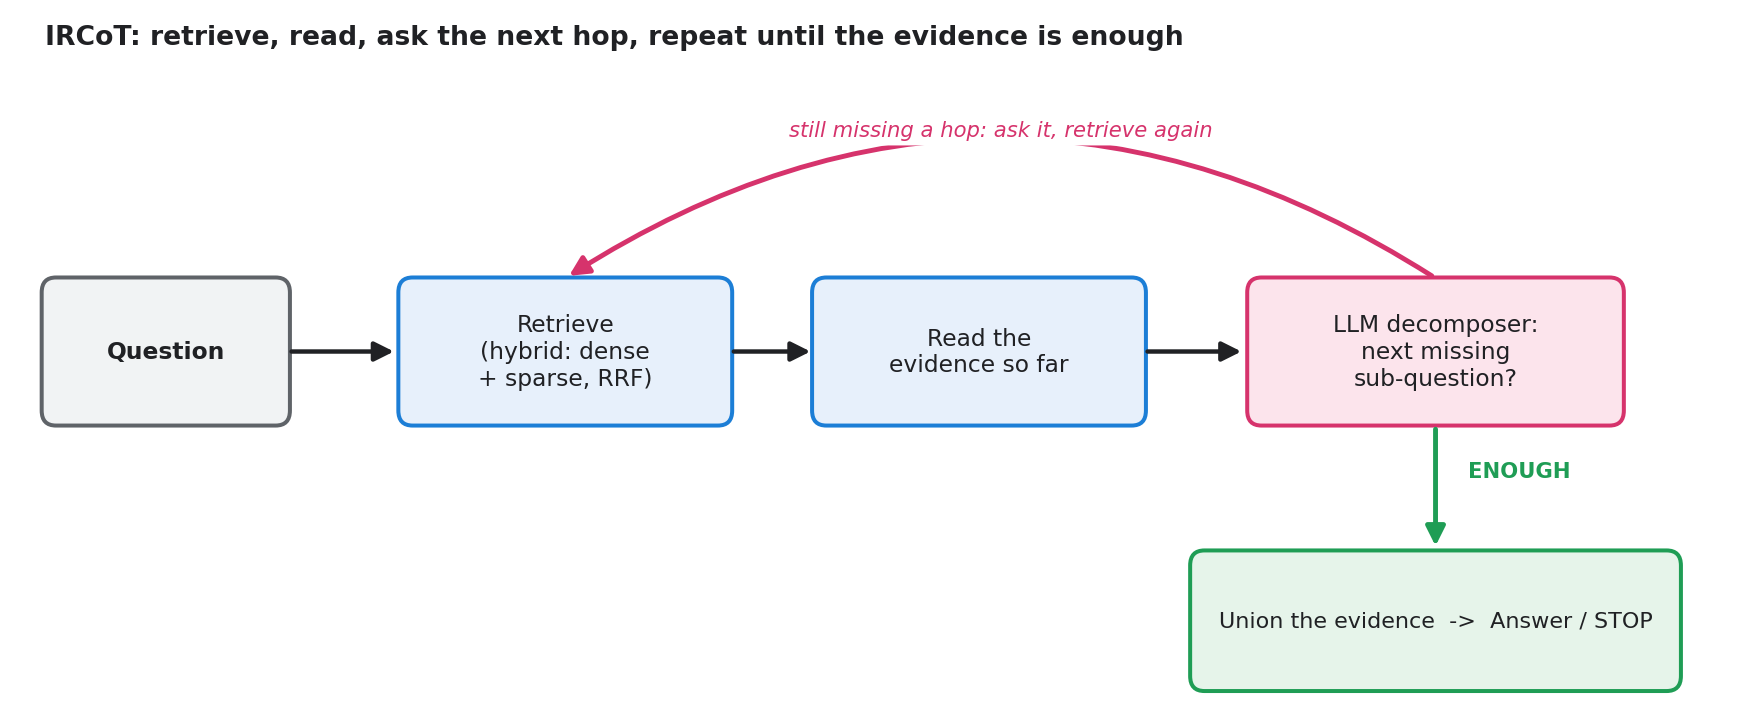

*The IRCoT loop. CP1 uses it as the mental model; CP3 turns it into `decompose()`.*

What to notice on the Jim Wilson question:

> *What sea washes the shores of the birthplace of Jim Wilson?*

- Hop 1 is reachable from the question as written: Jim Wilson's birthplace.
- Hop 2 is not reachable until Hop 1 reveals the bridge entity: County Antrim.

In [ ]:
multi = by_id["2hop__615262_131886"]
gold = set(multi["gold_doc_ids"])

print(f"Q: {multi['question']}\n")
print("baseline retrieve, question as written (top-3):")
show_hits(hybrid_search(multi["question"]), gold)

Only one of the two required passages appears in the top results: the first-hop passage that identifies the birthplace location. The second-hop passage containing the answer never appears, even within the top 50 results from either retriever. The problem is missing evidence, not poor ranking.

## CP2: metrics, signals, and the gate

A signal is a low-cost metric computed from retrieval results. It predicts whether retrieval is likely to be weak
before the agent decides to run more expensive steps.

A useful signal must satisfy two criteria:

1. It separates good retrievals from weak retrievals on calibration data.
2. It is cheap enough to run on every query.

The flow is: gold labels define weak retrieval during calibration, signals predict it,
thresholds turn those signals into a gate, and the gate decides whether to invoke additional retrieval stages.

### The candidates, by family

We test five candidate signals. The important split is whether the signal reads the already-fused
hybrid result or asks Qdrant for one extra raw retriever view.

| family | signal | what it reads | flags weak when | tends to matter on |
|---|---|---|---|---|
| height | `max_score` | top-1 fused score | low | score-calibrated single-retriever setups |
| spread (fused) | `score_variance` | spread of the fused top-k scores | low (flat ranking) | corpora where fusion keeps score range |
| spread (raw) | `dense_variance` | spread of the **raw dense** cosines | low (dense can't separate its hits) | most dense-retrieval corpora |
| coverage | `evidence_coverage` | question entities present in the top-k text | low (text misses them) | entity-lookup / keyword data |
| agreement | `retriever_divergence` | dense vs miniCOIL top-k overlap | high (they disagree) | lexical-mismatch / jargon / OOV data |

What to notice: RRF is great for combining ranks, but it flattens score shape. So we test both fused
score spread and raw dense cosine spread. The first is free; the second costs one extra Qdrant query
but no extra model call.

First define the extra reads some signals need: raw dense ranking, raw miniCOIL ranking, and a small
entity extractor for the coverage signal.

In [ ]:
def dense_ranking(question, enc=None):
    # the RAW dense cosine ranking, pre-fusion: [(doc_id, cosine), ...].
    # Reuses the BGE embedding the hybrid query already computes.
    dense, _minicoil = enc or embed(question)
    pts = client.query_points(COLLECTION, query=dense, using=DENSE_VEC, limit=TOP_K, with_payload=False).points
    return [(p.id, p.score) for p in pts]

def minicoil_ranking(question, enc=None):
    # the RAW miniCOIL ranking, pre-fusion: [doc_id, ...].
    # Reuses the miniCOIL embedding the hybrid query already computes.
    _dense, minicoil = enc or embed(question)
    pts = client.query_points(
        COLLECTION,
        query=models.SparseVector(indices=minicoil.indices.tolist(), values=minicoil.values.tolist()),
        using=MINICOIL_VEC, limit=TOP_K, with_payload=False).points
    return [p.id for p in pts]

_QUESTION_STOP = {"what", "who", "whom", "whose", "where", "when", "which", "why", "how",
                  "is", "was", "are", "were", "did", "do", "does", "the", "a", "an", "name",
                  "in", "of", "on", "at", "to", "for", "by", "as", "that", "this"}
_NAME_CONNECTORS = {"of", "the", "and", "de", "von", "van", "del", "la", "el", "da", "di", "&"}

def question_entities(question):
    # Computes what fraction of the question's entities actually appear in the fused top-k passage text.
    # For "Who directed the 1994 film Pulp Fiction?" you'd get roughly {"pulp fiction", "1994"}
    # Used for the coverage signal.
    toks = (question or "").split()
    ents, cur = [], []
    for i, tok in enumerate(toks):
        w = tok.strip(string.punctuation)
        if not w:
            if cur:
                ents.append(" ".join(cur)); cur = []
            continue
        is_cap = w[0].isupper()
        if is_cap and not (i == 0 and w.lower() in _QUESTION_STOP):
            cur.append(w)
        elif cur and w.lower() in _NAME_CONNECTORS and i + 1 < len(toks) \
                and toks[i + 1].strip(string.punctuation)[:1].isupper():
            cur.append(w)
        elif cur:
            ents.append(" ".join(cur)); cur = []
    if cur:
        ents.append(" ".join(cur))
    out = {e.lower() for e in ents if len(e) >= 2}
    out |= set(re.findall(r"\b\d{4}\b", question or ""))
    return out

Now define the five candidate signals. `retrieve_signals` runs the shared reads once, then each
signal reads one simple value from those results.

In [ ]:
def retrieve_signals(question, enc=None):
    # one encode, three reads: the fused hybrid result + the two raw single-retriever rankings.
    enc = enc or embed(question)
    return hybrid_search(question, enc=enc), dense_ranking(question, enc=enc), minicoil_ranking(question, enc=enc)

def max_score(fused):       return fused[0].score                                  # height: top-1 fused score
def score_variance(fused):  return statistics.pstdev([p.score for p in fused])     # spread of the FUSED scores
def dense_variance(dense):  return statistics.pstdev([s for _, s in dense])        # spread of the RAW DENSE cosines

def evidence_coverage(question, fused):                                            # coverage: question entities present?
    ents = question_entities(question)
    if not ents:
        return 1.0
    blob = " ".join(f"{p.payload['title']} {p.payload['text']}" for p in fused).lower()
    return sum(1 for e in ents if e in blob) / len(ents)

def retriever_divergence(dense, sparse_ids):                                       # agreement: dense vs miniCOIL disjointness
    dense_ids = [i for i, _ in dense]
    return 1.0 - len(set(dense_ids) & set(sparse_ids)) / max(len(dense_ids), len(sparse_ids))

**How we pick signals, computed live.** On calibration data we know whether the top-3 contains all
supporting passages. At runtime we will not know that, so each signal is scored by how well it
separates good retrievals from weak retrievals.

The code reports AUC, which you can read as a separation score: 0.5 is chance, 1.0 is perfect. This
cell runs live over about 150 calibration questions with Qdrant only; no LLM calls.

In [ ]:
# The frozen calibration split (seed 5252) only picks WHICH ~150 questions to score; every signal
# value and label below is computed LIVE. The full_gold@3 label = all gold docs inside the fused top-3.
manifest = json.loads((REPO / "artifacts/mixed_manifest.json").read_text())
cal_sel = manifest["splits"]["calibration"]
cal_ids = [*cal_sel["single"], *cal_sel["multi"], *cal_sel["unanswerable"]]
cal_questions = [by_id[i] for i in cal_ids if by_id[i].get("answerable") and by_id[i].get("gold_doc_ids")]

def feature_row(q):
    fused, dense, sparse_ids = retrieve_signals(q["question"])
    gold = set(q["gold_doc_ids"])
    return {
        "full_gold_label": 1 if gold.issubset({p.id for p in fused[:ANSWER_K]}) else 0,
        "dense_variance": dense_variance(dense), "score_variance": score_variance(fused),
        "max_score": max_score(fused), "evidence_coverage": evidence_coverage(q["question"], fused),
        "retriever_divergence": retriever_divergence(dense, sparse_ids),
    }

calibration = [feature_row(q) for q in cal_questions]
print(f"benchmarked {len(calibration)} calibration questions live; "
      f"{sum(r['full_gold_label'] for r in calibration)} good / "
      f"{sum(1 - r['full_gold_label'] for r in calibration)} weak retrievals")

The catalog below applies two rules: keep signals with separation score at least **0.65**, then drop
near-duplicates of a stronger kept signal (absolute correlation above **0.85**).

In [ ]:
labels = [r["full_gold_label"] for r in calibration]
AUC_BAR, CORR_MAX = 0.65, 0.85

SIGNAL_COLUMN = {   # signal -> the feature-matrix column it reads (divergence is stored per detector)
    "dense_variance": "dense_variance",
    "score_variance": "score_variance",
    "max_score": "max_score",
    "evidence_coverage": "evidence_coverage",
    "retriever_divergence": "retriever_divergence",
}

def signal_auc(name):
    raw = roc_auc_score(labels, [r[SIGNAL_COLUMN[name]] for r in calibration])
    return max(raw, 1 - raw)            # separation strength, regardless of direction

def abs_corr(a, b):
    return abs(float(np.corrcoef([r[SIGNAL_COLUMN[a]] for r in calibration],
                                 [r[SIGNAL_COLUMN[b]] for r in calibration])[0, 1]))

aucs = {name: signal_auc(name) for name in SIGNAL_COLUMN}

# apply the rule live: above the AUC bar, then drop any near-duplicate of a stronger kept signal
kept = []
for name in sorted((n for n in aucs if aucs[n] >= AUC_BAR), key=lambda n: -aucs[n]):
    if all(abs_corr(name, k) <= CORR_MAX for k in kept):
        kept.append(name)
kept = set(kept)

catalog = pd.DataFrame([
    {"signal": name, "AUC": aucs[name], "verdict": "kept" if name in kept else "dropped"}
    for name in sorted(aucs, key=lambda n: -aucs[n])
])
catalog

Three of the five drop out here. Two do not separate well enough; one is a duplicate of a stronger
signal.

The same benchmark as a picture. When the good and weak boxes pull apart, the signal separates; when
they overlap, it does not.

In [ ]:
plot_signal_separation(calibration, aucs, kept, SIGNAL_COLUMN)

In production, select signals on one split, tune thresholds on another, and keep test
held out. The method carries over; the winning signals are corpus-specific.

### The gate: turning signals into a decision

The gate decides whether to answer with the current retrieval results or escalate to a more expensive retrieval step.

Each signal has a threshold. Raising the threshold catches more weak retrievals but escalates more queries; lowering it does the opposite.

The helper below selects a threshold from the calibration set. By default, `youden_floor` chooses the best balance between catching weak retrievals and avoiding false alarms, though you can also target a specific recall (for example, catching 90% of weak retrievals).

In [ ]:
weak = [r["full_gold_label"] == 0 for r in calibration]    # True = retrieval was weak (gold not all in top-3)

def youden_floor(values):
    # The "fires below" floor that best separates weak from healthy retrievals on calibration.
    best = None
    for thr in sorted(set(values)):
        pred = [v < thr for v in values]
        tp = sum(1 for p, w in zip(pred, weak) if p and w)
        fp = sum(1 for p, w in zip(pred, weak) if p and not w)
        fn = sum(1 for p, w in zip(pred, weak) if not p and w)
        tn = sum(1 for p, w in zip(pred, weak) if not p and not w)
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        if best is None or (tpr - fpr) > best[1]:
            best = (thr, tpr - fpr)
    return best[0]

DV_FLOOR = youden_floor([r["dense_variance"] for r in calibration])
SV_FLOOR = youden_floor([r["score_variance"] for r in calibration])
print(f"calibrated floors:  dense_variance < {DV_FLOOR:.5f}   score_variance < {SV_FLOOR:.5f}\n")

# the operating point of the primary floor, read off the same calibration features
fires = [r["dense_variance"] < DV_FLOOR for r in calibration]
tp = sum(f and w for f, w in zip(fires, weak)); fp = sum(f and not w for f, w in zip(fires, weak))
fn = sum((not f) and w for f, w in zip(fires, weak))
print("at the dense_variance floor:")
print(f"  precision       = {tp / (tp + fp):.3f}   (of the queries we escalate, how many were truly weak)")
print(f"  recall          = {tp / (tp + fn):.3f}   (of the truly weak queries, how many we catch)")
print(f"  escalation rate = {sum(fires) / len(fires):.2f}   (fraction of queries sent past tier 1)")

The plot shows where the floor sits on the good-vs-weak distributions, and what it buys: how much of
the weak (red) mass falls below the line (caught) versus how much of all traffic does (escalated).
Healthy queries below the line are wasted escalations; weak ones above it are misses. `score_variance`
uses the same process.

In [ ]:
plot_gate(calibration, DV_FLOOR)

In [ ]:
plot_gate(calibration, SV_FLOOR, signal="score_variance")

Now wire the gate the loop will call.

The gate reads `score_variance` from the hybrid result and `dense_variance` from the dense-only
ranking. If either signal falls below its threshold, retrieval is treated as weak.

In [ ]:
def retrieval_is_weak(fused, dense):
    # the tier-1 gate: escalate if EITHER kept signal is below its calibrated floor.
    return score_variance(fused) < SV_FLOOR or dense_variance(dense) < DV_FLOOR

### Optional: catch more by targeting recall

The Youden floor balances catches against false alarms. If a missed weak retrieval costs you more than an extra escalation, set the floor to hit a **recall target** instead - catch a larger share of weak retrievals, at the price of escalating more. This is a standalone illustration; the loop keeps using the balanced floors above.

In [ ]:
def floor_for_recall(values, target):
    # gate fires below the floor; recall rises as the floor rises, so return the smallest floor
    # (least over-escalation) that still catches >= `target` of the weak retrievals.
    for thr in sorted(set(values)):
        pred = [v < thr for v in values]
        caught = sum(1 for p, w in zip(pred, weak) if p and w)
        if caught / sum(weak) >= target:
            return thr
    return max(values)

dv = [r["dense_variance"] for r in calibration]

def _gate_stats(floor):
    fires = [v < floor for v in dv]
    caught = sum(1 for f, w in zip(fires, weak) if f and w)
    return caught / sum(weak), sum(fires) / len(fires)   # recall, escalation rate

for label, floor in [("Youden (balanced)", DV_FLOOR), ("recall target 0.90", floor_for_recall(dv, 0.90))]:
    rec, esc = _gate_stats(floor)
    print(f"{label:20s}  floor {floor:.4f}  ->  catches {rec:.0%} of weak, escalates {esc:.0%}")

## CP3: wire the corrective loop

CP2 tells us when retrieval looks weak. CP3 decides what to do about it.

The two corrective actions map to two different failure modes:

- weak single-hop lookup: the right passage exists but is ranked too low
- weak multi-hop query: the next needed passage is not reachable until the agent asks a follow-up

### Tier 2: ColBERT late interaction (single-hop precision)

ColBERT is the ranking fix. It scores query tokens against passage tokens, which can promote a
specific passage that the pooled dense vector blurred away. The Qdrant call below fetches a dense
candidate pool, then rescoring uses the ColBERT multivector.

In [ ]:
def colbert_rerank(question, limit=TOP_K, enc=None):
    # Qdrant native multivector: prefetch a dense pool, rescore with ColBERT MaxSim (late interaction).
    dense, _minicoil = enc or embed(question)
    colbert_vecs = [v.tolist() for v in next(iter(colbert_model.query_embed(question)))]
    return client.query_points(
        COLBERT_COLLECTION,
        prefetch=[models.Prefetch(query=dense, using=DENSE_VEC, limit=RETRIEVE_N)],
        query=colbert_vecs, using=COLBERT_VEC, limit=limit, with_payload=True,
    ).points

tier2 = by_id["2hop__82744_23140__h0"]            # a weak single-hop lookup
gold = tier2["gold_doc_ids"]
print(f"Q: {tier2['question']}\n")
print("hybrid retrieve, supporting passage buried:")
show_hits(hybrid_search(tier2["question"]), gold)
print("\nColBERT late interaction, the right passage promoted:")
show_hits(colbert_rerank(tier2["question"]), gold)

Hybrid retrieval matched the entity "Nigeria" and buried the passage containing the actual answer, the GDP table. ColBERT reranked that passage to rank 1. While ColBERT provides little average gain across the full validation set, it improves precision on the weak retrievals routed to it by the gate. Other rerankers, including cross-encoders, are viable alternatives, but ColBERT produced the best results on this corpus.

### Tier 3: decompose (IRCoT) for multi-hop recall

A reranker can only reorder passages that were already retrieved. When the needed evidence is missing, the agent switches to decomposition: it reviews the evidence collected so far, generates the next sub-question, retrieves again, and repeats until enough evidence has been gathered to answer the original question.

In [ ]:
IRCOT_SYSTEM = (
    "You are running an iterative retrieve-and-reason loop to answer a multi-hop "
    "question. Given the main question, the evidence retrieved so far, and the "
    "sub-questions already asked, output the NEXT single sub-question whose answer is "
    "still MISSING and is needed to answer the main question. Make it self-contained: "
    "name entities explicitly, resolving any bridge entity from the evidence so far. "
    "If the evidence already contains everything needed to answer the main question, "
    "reply with exactly: ENOUGH. Output ONLY the sub-question text or ENOUGH - no prose."
)

def evidence_digest(pools, max_docs=6, max_chars=160):
    # a short, deduped digest of the evidence retrieved so far, to condition the next sub-query.
    seen, lines = set(), []
    for pool in pools:
        for c in pool:
            if c.doc_id in seen:
                continue
            seen.add(c.doc_id)
            lines.append(f"- {c.title}: {(c.text or '')[:max_chars]}")
            if len(lines) >= max_docs:
                return "\n".join(lines)
    return "\n".join(lines) if lines else "(none)"

def next_subquery(question, pools, sub_queries):
    # the LLM reads the evidence so far and asks the next still-missing sub-question (or ENOUGH).
    user = (
        f"Main question: {question}\n\n"
        f"Evidence so far:\n{evidence_digest(pools)}\n\n"
        "Sub-questions already asked:\n" + ("\n".join(f"- {s}" for s in sub_queries) or "(none)") +
        "\n\nNext sub-question (or ENOUGH):"
    )
    text = ask_llm(IRCOT_SYSTEM, user, max_tokens=80)
    t = (text or "").strip()
    if not t or t.upper().startswith("ENOUGH"):
        return None
    return re.sub(r"^[\-\d\.\)\s]+", "", t.splitlines()[0]).strip() or None

def union_pool(pools, k=TOP_K):
    # merge the per-hop passage pools, keeping the MAX score per doc, take the top-k. This is what
    # lets a later hop's strongest passage surface into the final set (the missing-hop recovery).
    best = {}
    for pool in pools:
        for c in pool:
            if c.doc_id not in best or c.score > best[c.doc_id].score:
                best[c.doc_id] = c
    return sorted(best.values(), key=lambda c: c.score, reverse=True)[:k]

def decompose_with_trace(question, max_hops=4, hop0=None):
    # IRCoT with trace: keep each hop's query and passage pool so we can inspect the path.
    pools = [hop0 if hop0 is not None else to_passages(hybrid_search(question))]
    sub_queries = []
    for _ in range(max_hops - 1):
        next_q = next_subquery(question, pools, sub_queries)
        if next_q is None:
            break
        sub_queries.append(next_q)
        pools.append(to_passages(hybrid_search(next_q)))
    return union_pool(pools, TOP_K), sub_queries, pools

def decompose(question, max_hops=4, hop0=None):
    # Normal call site: return just the final pool and the generated sub-questions.
    pool, sub_queries, _pools = decompose_with_trace(question, max_hops=max_hops, hop0=hop0)
    return pool, sub_queries

multi = by_id["2hop__615262_131886"]
gold = multi["gold_doc_ids"]
print(f"Q: {multi['question']}\n")
print("hybrid retrieve (single pass), only the first hop is reachable:")
show_hits(hybrid_search(multi["question"]), gold)

pool, sub_queries = decompose(multi["question"])
print("\ndecompose reads hop 1, then asks the still-missing sub-question:")
for sub_question in sub_queries:
    print(f"  -> {sub_question}")
print("\nunioned evidence, the second supporting passage now in context:")
show_hits(pool, gold, k=4)

### The assembled loop: `solve()`

Now we put the pieces together. `solve()` retrieves once, then evaluates the gate to decide whether to escalate and what the cheapest fix should be. The gate controls *whether* to escalate, while the question shape (`looks_multi_hop`) controls *how* to escalate.

- Single-hop issue → ColBERT reranking fixes ordering errors.
- Multi-hop issue → decomposition retrieves missing evidence.

`generate_answer()` only reads the top-3 passages and returns `INSUFFICIENT_CONTEXT` when the evidence is not sufficient.


In [ ]:
ANSWER_SYSTEM = (
    "You answer a question using ONLY the numbered context passages provided. "
    "Reply with ONLY the final answer on a single line: a name, date, number, or short "
    "noun phrase, usually one to six words. Do NOT show reasoning or steps, do NOT "
    "restate the question, do NOT write 'I need to find', do NOT explain. Output just "
    "the answer text. If the passages do not contain the information needed to answer, "
    "reply with exactly: INSUFFICIENT_CONTEXT"
)

def generate_answer(question, passages):
    # Claude answers grounded in the focused top-ANSWER_K passages, or emits INSUFFICIENT_CONTEXT.
    if not passages:
        return "INSUFFICIENT_CONTEXT"
    ctx = "\n".join(f"[{i}] {c.title}. {(c.text or '')[:700]}"
                    for i, c in enumerate(passages[:ANSWER_K], 1))
    text = ask_llm(ANSWER_SYSTEM, f"Context:\n{ctx}\n\nQuestion: {question}\nAnswer (answer only):",
                   max_tokens=150)
    t = (text or "").strip()
    if "INSUFFICIENT_CONTEXT" in t.upper() or not t:
        return "INSUFFICIENT_CONTEXT"
    last = [ln.strip() for ln in t.splitlines() if ln.strip()][-1]
    return re.sub(r"^(answer|the answer is|final answer)[:\-\s]+", "", last, flags=re.I).strip()

def looks_multi_hop(question):
    # cheap, gold-free router: >= 2 named entities or a long question -> likely a missing hop.
    return len(question_entities(question)) >= 2 or len(question.split()) >= 12

def solve(question):
    # the self-correcting retrieval loop: retrieve once, read the signal, climb only as far as needed.
    enc = embed(question)
    fused = hybrid_search(question, enc=enc)            # the base retrieval, reused below
    dense = dense_ranking(question, enc=enc)            # the one extra read the gate needs
    if not retrieval_is_weak(fused, dense):
        return to_passages(fused), "tier 1: confident, answer from the hybrid top-3"
    if looks_multi_hop(question):
        pool, sub_queries = decompose(question, hop0=to_passages(fused))
        return pool, f"tier 3: weak + multi-hop, decomposed ({len(sub_queries)} sub-question(s))"
    return to_passages(colbert_rerank(question, enc=enc)), "tier 2: weak single-hop, ColBERT late-interaction"

Three queries, three paths from one agent. This runs the full loop live.

In [ ]:
routing_demos = [
    # Retrieves specific questions from the validation set
    ("confident single-hop", "2hop__101521_42157__h0"), # Which continent is Atbarah River located?
    ("weak single-hop",      "2hop__130545_45439__h0"), # What state is Chesapeake City Bridge located?
    ("multi-hop",            "2hop__615262_131886"), # What sea washes on the shores of the birthplace of Jim Wilson?
]
for label, qid in routing_demos:
    q = by_id[qid]
    pool, route = solve(q["question"])
    answer = generate_answer(q["question"], pool)
    print(f"[{label}]")
    show_run(q["question"], route, answer, pool, q["gold_doc_ids"])

### STOP: decide whether to answer

Routing asks, "Should I spend more retrieval?" STOP asks, "Should I answer at all?"

The default **gentle stop** is built into `generate_answer()`: the answer prompt says "use only this
context; if it is not enough, return `INSUFFICIENT_CONTEXT`." No extra model call is made. This keeps
answerable questions flowing, but it relies on the answer model to notice missing evidence.

The stricter option is a separate **sufficiency judge**. It reads the same top-3 answer context and
answers one question: does this context contain every fact needed to answer? It catches more
unanswerables, but it can also over-refuse answerable questions.

In [ ]:
SUFFICIENCY_SYSTEM = (
    "Judge whether the provided context contains enough information to answer the question. "
    "Use ONLY the context. Reply with exactly one word: SUFFICIENT or INSUFFICIENT."
)

def sufficiency_judge(question, passages):
    # Strict STOP autorater: is every fact needed by the question present in the answer context?
    if not passages:
        return False

    context = "\n".join(
        f"[{i}] {c.title}. {(c.text or '')[:600]}"
        for i, c in enumerate(passages, 1)
    )
    user = (
        f"Question:\n{question}\n\n"
        f"Context:\n{context}\n\n"
        "Can the question be answered completely from this context? "
        "Reply with exactly one word: SUFFICIENT or INSUFFICIENT."
    )

    try:
        text = ask_llm(SUFFICIENCY_SYSTEM, user, max_tokens=20, model=FAST_MODEL)
    except Exception:
        # On API failure, keep the gentle-stop behavior rather than adding a false refusal.
        return True

    decision_words = re.findall(r"[A-Z]+", (text or "").upper())
    if "INSUFFICIENT" in decision_words:
        return False
    if "SUFFICIENT" in decision_words:
        return True
    return True

The two STOP policies side by side. "Full workload handled" means the agent either answers correctly
or correctly refuses an unanswerable question.

In [ ]:
stop_variants = load_artifact("targeted_stop_v25.json")["variants"]   # offline eval, run once
stop_rows = [
    ("hybrid baseline + gentle",       "baseline_hybrid_gentle"),
    ("ladder + gentle (default)",      "ladder_gentle"),
    ("ladder + LLM sufficiency check", "ladder_autorater_all"),
]
pd.DataFrame([
    {"setup": label,
     "catches unanswerable": stop_variants[key]["abstain_unans"],
     "over-refuses answerable": stop_variants[key]["false_stop_ans"],
     "full workload handled": stop_variants[key]["selective_accuracy"]}
    for label, key in stop_rows
])

Here is one unanswerable run live. This traces the whole path: the first retrieval, the signal gate,
the decompose sub-questions, the final answer context, and both STOP decisions.

In [ ]:
unanswerable = by_id["2hop__108098_170204"]
question = unanswerable["question"]

print(f"Q: {question}\n")

enc = embed(question)
fused = hybrid_search(question, enc=enc)
dense = dense_ranking(question, enc=enc)
weak = retrieval_is_weak(fused, dense)

print("Step 1 - baseline hybrid retrieve:")
show_hits(fused, [], k=ANSWER_K)
print("Signal gate:")
print(f"  dense_variance = {dense_variance(dense):.5f}  floor = {DV_FLOOR:.5f}")
print(f"  score_variance = {score_variance(fused):.5f}  floor = {SV_FLOOR:.5f}")
print(f"  decision        = {'weak -> escalate' if weak else 'strong -> answer now'}")

if weak and looks_multi_hop(question):
    pool, sub_queries, hop_pools = decompose_with_trace(question, hop0=to_passages(fused))
    route = f"tier 3: weak + multi-hop, decomposed ({len(sub_queries)} sub-question(s))"
    for hop_idx, sub_question in enumerate(sub_queries, start=2):
        print(f"\nStep {hop_idx} - decomposer asks:")
        print(f"  {sub_question}")
        print("retrieved passages:")
        show_hits(hop_pools[hop_idx - 1], [], k=ANSWER_K)
    print(f"\nDecompose result: stopped after {len(sub_queries)} sub-question(s); pooled the evidence.")
elif weak:
    pool = to_passages(colbert_rerank(question, enc=enc))
    route = "tier 2: weak single-hop, ColBERT late-interaction"
else:
    pool = to_passages(fused)
    route = "tier 1: confident, answer from the hybrid top-3"

print(f"\nRoute: {route}")
print("\nFinal answer context:")
show_hits(pool, [], k=ANSWER_K)

gentle = generate_answer(question, pool)
sufficient = sufficiency_judge(question, pool[:ANSWER_K])

print("\nSTOP decisions:")
print(f"  gentle stop       = {'abstain' if gentle == 'INSUFFICIENT_CONTEXT' else 'answer'} ({gentle})")
print(f"  sufficiency judge = {'answer' if sufficient else 'abstain'}")

## Wrap: the scorecard (held-out test)

The final scorecard compares the adaptive ladder with fixed policies on the test slice. The answer
context is top-3, so the retrieval metrics focus on whether the needed support lands in that small
window:

| metric | what it answers |
|---|---|
| recall@3 | did at least one supporting passage make the answer context? |
| full_gold@3 | did every required supporting passage make the answer context? |
| MRR | how high did the first supporting passage rank? |
| cost | how many extra LLM calls or retrieval passes did the route spend? |
| latency | how long did the route take, end to end? |

In [ ]:
headline = load_artifact("headline_final_v25.json")    # offline eval, run once
frontier_test = frontier_table(headline["overall"], mrr_key="mrr_first", cost_key="llm_calls")
if "avg routing latency (s)" not in frontier_test.columns:
    latency = {
        name.replace("_", "-"): metrics.get("avg_latency_s")
        for name, metrics in headline["overall"].items()
    }
    frontier_test["avg routing latency (s)"] = frontier_test["policy"].map(latency)
display(frontier_test)

### What we learned

- **Route by evidence, not by question shape.** Cheap signals decide when the baseline result looks
  weak.
- **Match the fix to the failure.** ColBERT helps ranking problems; decompose helps missing-hop
  problems.
- **Measure cost and quality together.** The ladder is the cost-efficient point; always-decompose is
  the recall-heavy point.
- **STOP is separate from routing.** A better route can still need a deliberate abstention policy.

The specific winning signals are not portable. The method is: create candidate signals, benchmark
them against labeled retrieval outcomes, drop duplicates, tune thresholds, and measure the routed
loop end to end.

### How to adapt this to your workflow

To build a self-correcting loop on your own corpus:

1. **Set the answer context.** Decide how many passages the LLM reads.
2. **Label retrieval outcomes.** Define what "good enough" means for your task.
3. **Benchmark cheap signals.** Keep the ones that separate weak from healthy retrievals.
4. **Match fixes to failures.** Add the cheapest corrective action for each real failure mode.
5. **Measure the frontier.** Keep the loop only where quality justifies the added cost.
6. **Choose STOP deliberately.** Gentle by default; stricter when wrong answers are expensive.

Take home: this notebook, plus the `src/` package that mirrors it for reuse. 
https://github.com/qdrant-labs/self-correcting-loops-workshop